In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob

In [23]:
files = glob.glob("../output/2026-04-29_timestep_analysis/*.csv")
dfs = [pd.read_csv(file) for file in files]

dt_arr = []
drift_arr = []
drift_unc_arr = []

for df in dfs:
    dt_arr.append(df['time'][0] / 50) # data collected every 50 loops
    drift = df['drift']
    drift_arr.append(np.mean(drift))
    drift_unc_arr.append(np.std(drift) / np.sqrt(len(drift)))

combined_arr = list(zip(dt_arr, drift_arr, drift_unc_arr))
combined_arr.sort(key=lambda x: x[0])
dt_arr, drift_arr, drift_unc_arr = zip(*combined_arr)

(np.float64(-5.0700428380000006e-11), np.float64(-2.3354625591662605e-08), np.float64(-1.31661124882156e-07), np.float64(-3.1753304284779398e-06), np.float64(-1.16281034269152e-05), np.float64(-0.0002968142954328956), np.float64(-0.00119864332516591), np.float64(-0.029508282909220397), np.float64(-0.11657488427357), np.float64(-1.683222765113), np.float64(-1.8613632182998598))


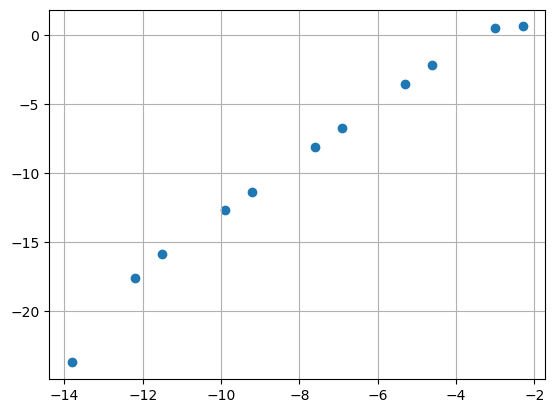

In [30]:
dt_log_arr = [np.log(dt) for dt in dt_arr]
drift_log_arr = [np.log(abs(drift)) for drift in drift_arr]
print(drift_arr)
plt.scatter(dt_log_arr, drift_log_arr)
plt.grid()